In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = sns.load_dataset("titanic")

In [4]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
sibsp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [7]:
df.describe(include='object').T

,count,unique,top,freq
sex,891,2,male,577
embarked,889,3,S,644
who,891,3,man,537
embark_town,889,3,Southampton,644
alive,891,2,no,549


In [8]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Text(0, 0.5, 'Count')

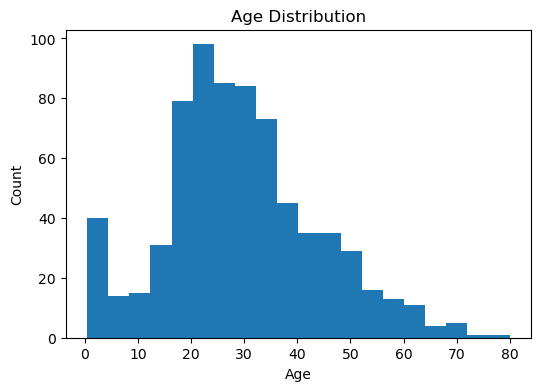

In [9]:
plt.figure(figsize=(6,4))
plt.hist(df["age"].dropna(),bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

Text(0.5, 1.0, 'Fare Boxplot')

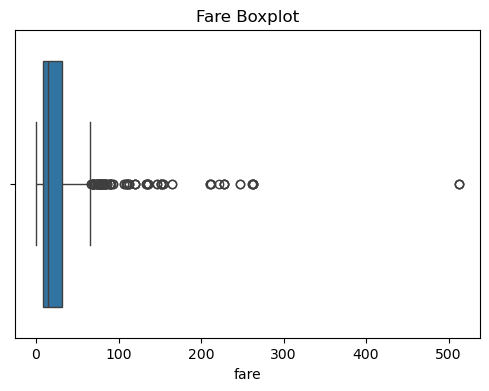

In [10]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["fare"])
plt.title("Fare Boxplot")

Text(0.5, 1.0, 'Passenger Gender Count')

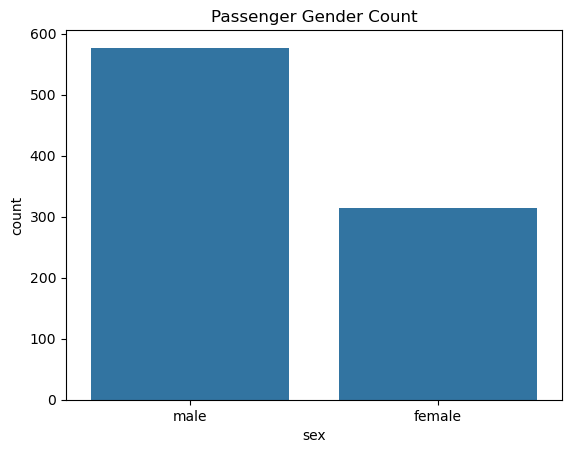

In [11]:
sns.countplot(x="sex",data=df)
plt.title("Passenger Gender Count")

Text(0.5, 1.0, 'Age vs Fare')

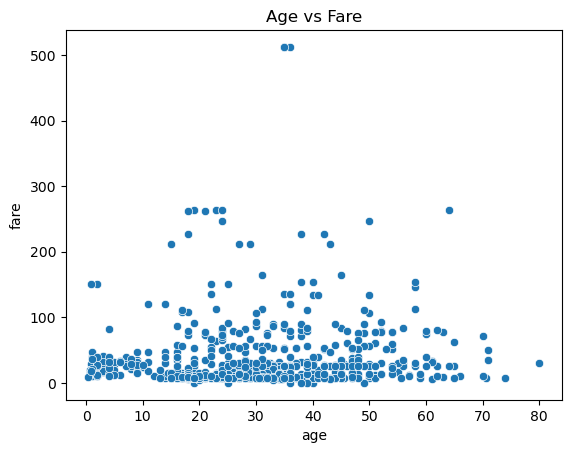

In [12]:
sns.scatterplot(x="age",y="fare",data=df)
plt.title("Age vs Fare")

Text(0.5, 1.0, 'Line Plot: Age vs Fare')

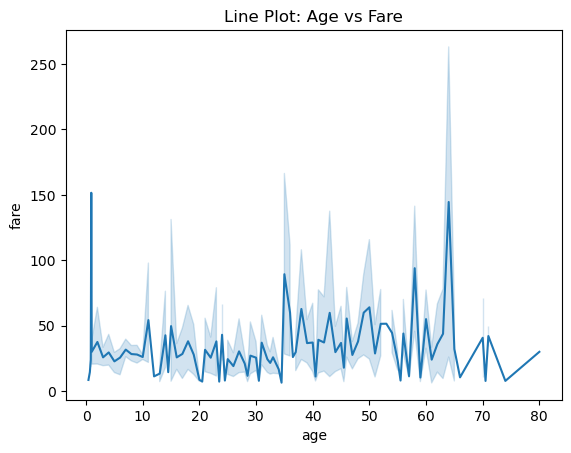

In [13]:
sns.lineplot(x="age",y="fare",data=df)
plt.title("Line Plot: Age vs Fare")

Text(0.5, 1.0, 'Age Distribution by Gender')

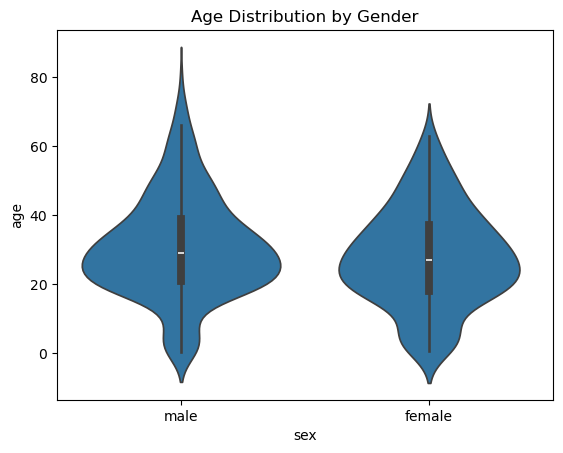

In [14]:
sns.violinplot(x="sex",y="age",data=df)
plt.title("Age Distribution by Gender")

Text(0.5, 1.0, 'Correlation Heatmap')

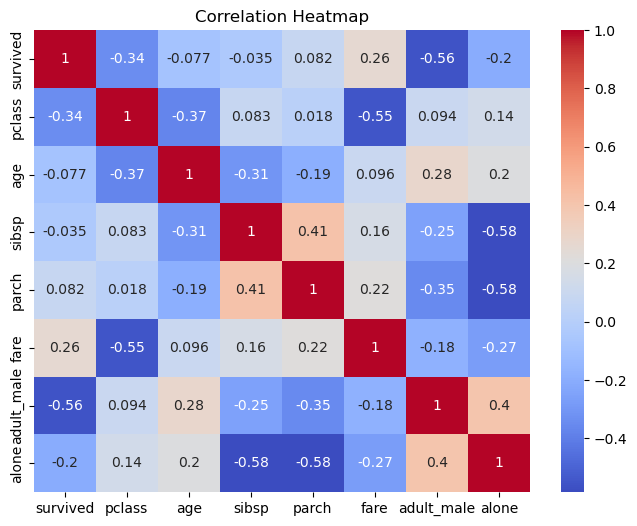

In [15]:
plt.figure(figsize=(8,6))
corr =df.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")

In [18]:
Q1 = df["fare"].quantile(0.25)

Q3 = df["fare"].quantile(0.75)

IQR = Q3-Q1

lower_bound=Q1-1.5*IQR

upper_bound=Q3+1.5*IQR

outliers = df[(df["fare"]<lower_bound) | df["fare"]>upper_bound]

print("Number of Outliers: ",len(outliers))

Number of Outliers:  0


Text(0.5, 1.0, 'Survival by Passenger Class')

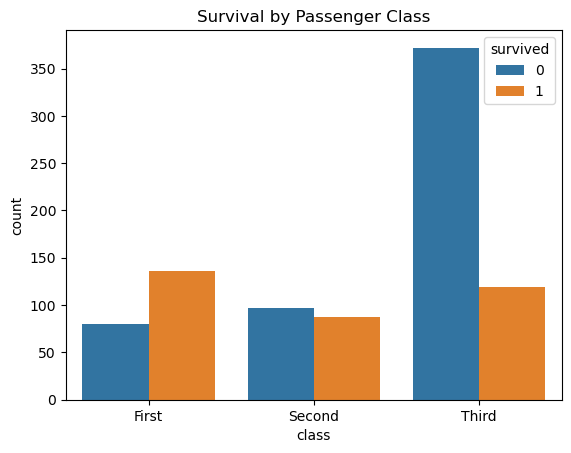

In [19]:
sns.countplot(x="class",hue="survived",data=df)
plt.title("Survival by Passenger Class")